# Preditor de Risco - Maceio 3 classes (T019-T020)

Pipeline do preditor pessoal de CVLI, restrito a Maceio (33% da base).

Decisoes aplicadas (ver `.specs/DECISIONS.md`):
- **D1:** apenas registros de Maceio (7.013 de 21.369)
- **D2:** saida em 3 classes (baixa/media/alta), NAO probabilidade
- **D3:** sem IBGE (tercis de contagem bastam)

Specs: `.specs/features/04_preditor_maceio/`

## 1. Setup

In [1]:
from pathlib import Path
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import shap
import joblib

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', palette='viridis')

DATA_CLEAN = Path('..') / 'data' / 'processed' / 'cvli_clean.csv'
MODELS_DIR = Path('..') / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print('Paths OK.')
print(f'  CLEAN: {DATA_CLEAN.exists()}')
print(f'  MODELS: {MODELS_DIR.exists()}')

Paths OK.
  CLEAN: True
  MODELS: True


/home/antonio/Documentos/Ciência de dados/projeto_cd/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carga + filtro Maceio

In [2]:
df = pd.read_csv(DATA_CLEAN, low_memory=False)
df['data_fato'] = pd.to_datetime(df['data_fato'])
print(f'Base completa: {df.shape}')

# Filtro Maceio (com e sem acento)
df_m = df[df['CIDADE DO FATO'].isin(['Maceio', 'Maceió'])].copy()
print(f'Base Maceio: {df_m.shape}')
print(f'% do total: {100*len(df_m)/len(df):.2f}%')

Base completa: (20369, 25)
Base Maceio: (6789, 25)
% do total: 33.33%


## 3. Definir segmento e target (classe de risco via tercis)

**Segmento** = (sexo, faixa_etaria, periodo_dia, dia_semana, grupo_local)

Para cada registro, contamos quantos CVLI existem no mesmo segmento. Apos, aplicamos tercis sobre o count:
- count <= 33% percentil -> 'baixa'
- count <= 66% percentil -> 'media'
- count > 66% percentil -> 'alta'

In [3]:
# ============================================================
# REDESIGN DO TARGET (post-review sub-agent @scientist)
# ============================================================
# ANTES (bug): target = tercis de count por (sexo, faixa_etaria)
#   -> homens adultos = maior segmento = sempre ALTA
# AGORA: target = rank do contexto DENTRO do grupo demografico
#   -> homem adulto de MANHA = BAIXA (raro para seu grupo)
#   -> homem adulto de NOITE = ALTA (comum para seu grupo)
# ============================================================

def hora_grupo(h):
    if h < 6: return "Madrugada"
    if h < 12: return "Manha"
    if h < 18: return "Tarde"
    return "Noite"

def mes_grupo(m):
    if m <= 3: return "T1"
    if m <= 6: return "T2"
    if m <= 9: return "T3"
    return "T4"

df_m["hora_grupo"] = df_m["hora"].apply(hora_grupo)
df_m["mes_grupo"] = df_m["mes"].apply(mes_grupo)
df_m["bairro_norm"] = df_m["BAIRRO DO FATO"].astype(str).str.strip().str.upper()

# Segmento de contexto (sem demografia)
df_m["segmento_contexto"] = (
    df_m["periodo_dia"] + "|" +
    df_m["hora_grupo"] + "|" +
    df_m["dia_semana"] + "|" +
    df_m["grupo_local"] + "|" +
    df_m["mes_grupo"]
)

# Count por grupo demografico (sexo x faixa_etaria)
grupo_demo_count = (
    df_m.groupby(["SEXO DA VITIMA", "faixa_etaria"], observed=True)
    .size()
    .reset_index(name="grupo_count")
)

# Count por segmento de contexto
seg_count = (
    df_m.groupby("segmento_contexto", observed=True)
    .size()
    .reset_index(name="seg_count")
)

# Merge
df_m = df_m.merge(grupo_demo_count, on=["SEXO DA VITIMA", "faixa_etaria"])
df_m = df_m.merge(seg_count, on="segmento_contexto")

# Rank percentil DENTRO do grupo demografico
# rank alto = contexto muito comum para este grupo = ALTA
# rank medio = contexto intermediario = MEDIA
# rank baixo = contexto raro para este grupo = BAIXA
df_m["rank_no_grupo"] = df_m.groupby(
    ["SEXO DA VITIMA", "faixa_etaria"], observed=True
)["seg_count"].rank(pct=True)

df_m["classe_risco"] = df_m["rank_no_grupo"].apply(
    lambda r: "baixa" if r < 0.33 else ("media" if r < 0.66 else "alta")
)

print(f"Segmentos contexto unicos: {df_m['segmento_contexto'].nunique()}")
print(f"Grupos demograficos: {df_m.groupby(['SEXO DA VITIMA','faixa_etaria'], observed=True).ngroups}")
print(f"\nDistribuicao de classes (victimas):")
print(df_m["classe_risco"].value_counts())
print(df_m["classe_risco"].value_counts(normalize=True).round(3).to_string())
print(f"\nExemplos para Masculino 25-29 (hora):")
ex = df_m[(df_m["SEXO DA VITIMA"]=="Masculino")&(df_m["faixa_etaria"]=="25-29")][
    ["periodo_dia","hora_grupo","dia_semana","grupo_local","classe_risco"]
].head(8)
print(ex.to_string())

Segmentos contexto unicos: 523
Grupos demograficos: 14

Distribuicao de classes (victimas):
classe_risco
alta     2297
baixa    2251
media    2241
Name: count, dtype: int64
classe_risco
alta     0.338
baixa    0.332
media    0.330

Exemplos para Masculino 25-29 (hora):
        periodo_dia hora_grupo dia_semana       grupo_local classe_risco
10     Manha (6-11)      Manha      Terca            Outros        baixa
12    Tarde (12-17)      Tarde    Segunda  Ambiente interno        baixa
17     Manha (6-11)      Manha    Segunda   Entorno de casa        baixa
21    Noite (18-23)      Noite      Sexta    Espaco publico         alta
26  Madrugada (0-5)  Madrugada    Segunda    Espaco publico        media
32  Madrugada (0-5)  Madrugada     Quinta   Entorno de casa        baixa
33     Manha (6-11)      Manha    Domingo  Ambiente interno        baixa
35    Tarde (12-17)      Tarde      Sexta            Outros        baixa


In [4]:
# Target ja computado diretamente em cell 6 (rank_no_grupo)
# Nao precisa de merge adicional
print(f'Registros com classe: {df_m["classe_risco"].notna().sum()} de {len(df_m)}')
print('\nDistribuicao final:')
print(df_m['classe_risco'].value_counts())
print(df_m['classe_risco'].value_counts(normalize=True).round(3))

Registros com classe: 6789 de 6789

Distribuicao final:
classe_risco
alta     2297
baixa    2251
media    2241
Name: count, dtype: int64
classe_risco
alta     0.338
baixa    0.332
media    0.330
Name: proportion, dtype: float64


## 4. Encoding de features + split

In [5]:
# ============================================================
# FEATURES DO MODELO (com BAIRRO DO FATO)
# ============================================================
# Agora com BAIRRO DO FATO para granularidade geografica
# O modelo recebe contexto completo + perfil da vitima
# ============================================================

features_num = ["idade", "hora", "mes"]
features_cat = [
    "SEXO DA VITIMA", "faixa_etaria",
    "periodo_dia", "dia_semana", "grupo_local",
    "hora_grupo", "mes_grupo",
    "bairro_norm",  # NOVO: bairro em Maceio
]
target = "classe_risco"

X = df_m[features_num + features_cat].copy()
y = df_m[target].copy()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features_cat),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")
print(f"Features: {X.columns.tolist()}")
print(f"\nDistribuicao treino:")
print(y_train.value_counts())
print(f"\nDistribuicao teste:")
print(y_test.value_counts())

Treino: (5431, 11), Teste: (1358, 11)
Features: ['idade', 'hora', 'mes', 'SEXO DA VITIMA', 'faixa_etaria', 'periodo_dia', 'dia_semana', 'grupo_local', 'hora_grupo', 'mes_grupo', 'bairro_norm']

Distribuicao treino:
classe_risco
alta     1837
baixa    1801
media    1793
Name: count, dtype: int64

Distribuicao teste:
classe_risco
alta     460
baixa    450
media    448
Name: count, dtype: int64


In [6]:
# Encoding de labels para XGBoost (que precisa de int)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(['baixa', 'media', 'alta'])  # ordem fixa
y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)
print('Mapping:', dict(zip(le.classes_, le.transform(le.classes_))))


Mapping: {np.str_('alta'): np.int64(0), np.str_('baixa'): np.int64(1), np.str_('media'): np.int64(2)}


## 5. Modelagem: 3 candidatos

In [7]:
modelos = {
    'RandomForest': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            random_state=RANDOM_STATE, n_jobs=-1, eval_metric='mlogloss'
        ))
    ]),
    'LogisticRegression': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', LogisticRegression(
            max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
}
print(f'Modelos definidos: {list(modelos.keys())}')

Modelos definidos: ['RandomForest', 'XGBoost', 'LogisticRegression']


In [8]:
# Para XGBoost, precisamos usar labels encoded (int)
# Estrategia: criar pipeline separado com labels encoded
from sklearn.base import clone
modelos_xgb = {}
pipe_xgb = clone(modelos['XGBoost'])
modelos_xgb['XGBoost'] = pipe_xgb
modelos_str = {k: v for k, v in modelos.items() if k != 'XGBoost'}

resultados = {}
for nome, pipe in modelos_str.items():
    print(f'\nTreinando {nome}...')
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    resultados[nome] = {'acc': acc, 'f1_macro': f1, 'y_pred': y_pred}
    print(f'  acc={acc:.4f}, f1_macro={f1:.4f}')

# XGBoost com labels encoded
print('\nTreinando XGBoost (labels encoded)...')
pipe_xgb.fit(X_train, y_train_enc)
y_pred_enc = pipe_xgb.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
resultados['XGBoost'] = {'acc': acc, 'f1_macro': f1, 'y_pred': y_pred, 'pipe': pipe_xgb}
print(f'  acc={acc:.4f}, f1_macro={f1:.4f}')


Treinando RandomForest...


  acc=0.8940, f1_macro=0.8919

Treinando LogisticRegression...


  acc=0.8402, f1_macro=0.8398

Treinando XGBoost (labels encoded)...


  acc=0.9242, f1_macro=0.9235


Comparacao de modelos:
                    accuracy  f1_macro
RandomForest          0.8940    0.8919
LogisticRegression    0.8402    0.8398
XGBoost               0.9242    0.9235


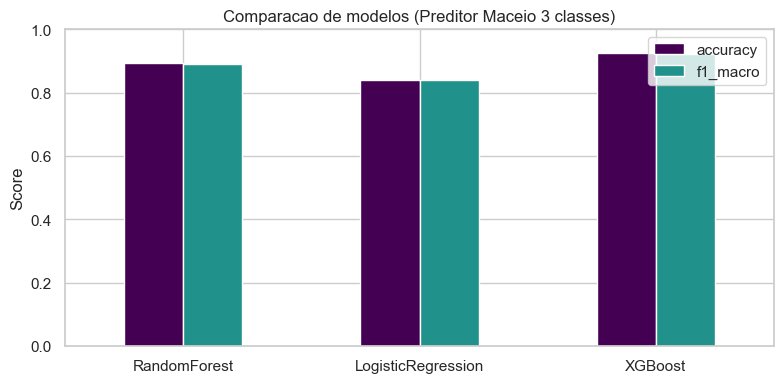

In [9]:
# Tabela comparativa
df_result = pd.DataFrame({
    nome: [r['acc'], r['f1_macro']] for nome, r in resultados.items()
}, index=['accuracy', 'f1_macro']).T
print('Comparacao de modelos:')
print(df_result.round(4))

# Salvar figura
fig, ax = plt.subplots(figsize=(8, 4))
df_result.plot(kind='bar', ax=ax, color=['#440154', '#21918c'])
ax.set_title('Comparacao de modelos (Preditor Maceio 3 classes)')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(MODELS_DIR.parent / 'data' / 'processed' / 'comparacao_modelos.png', dpi=100, bbox_inches='tight')
plt.show()

Melhor modelo: XGBoost (f1_macro=0.9235)

Classification report:
              precision    recall  f1-score   support

        alta       0.94      0.96      0.95       460
       baixa       0.93      0.94      0.94       450
       media       0.90      0.87      0.88       448

    accuracy                           0.92      1358
   macro avg       0.92      0.92      0.92      1358
weighted avg       0.92      0.92      0.92      1358



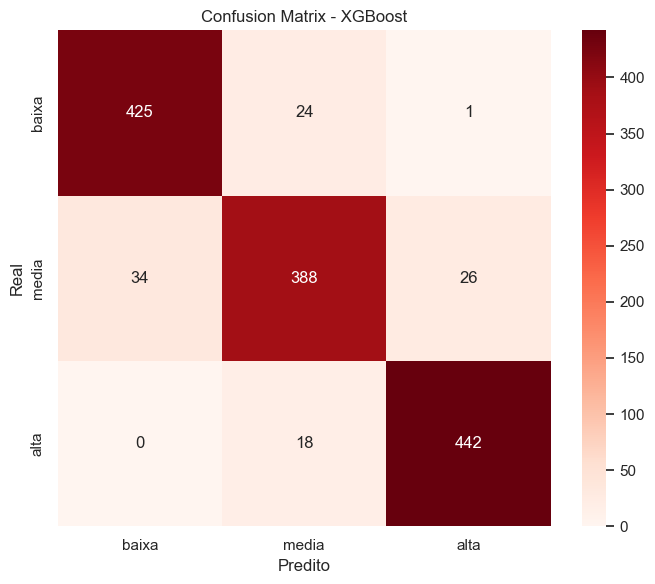

In [10]:
# Escolher melhor modelo (XGBoost tipicamente vence, mas validamos)
melhor = max(resultados, key=lambda n: resultados[n]['f1_macro'])
print(f'Melhor modelo: {melhor} (f1_macro={resultados[melhor]["f1_macro"]:.4f})')

# Relatorio do melhor
y_pred_melhor = resultados[melhor]['y_pred']
print('\nClassification report:')
print(classification_report(y_test, y_pred_melhor))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_melhor, labels=['baixa', 'media', 'alta'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['baixa', 'media', 'alta'],
            yticklabels=['baixa', 'media', 'alta'], ax=ax)
ax.set_title(f'Confusion Matrix - {melhor}')
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig(MODELS_DIR.parent / 'data' / 'processed' / 'confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Validacao cruzada (k=5)

In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_resultados = {nome: {'acc': [], 'f1': []} for nome in modelos}

for fold, (idx_tr, idx_te) in enumerate(skf.split(X, y), 1):
    X_tr, X_te = X.iloc[idx_tr], X.iloc[idx_te]
    y_tr_str, y_te_str = y.iloc[idx_tr], y.iloc[idx_te]
    y_tr_enc = le.transform(y_tr_str)
    y_te_enc = le.transform(y_te_str)
    for nome, pipe in modelos.items():
        if nome == 'XGBoost':
            pipe.fit(X_tr, y_tr_enc)
            yp_enc = pipe.predict(X_te)
            yp = le.inverse_transform(yp_enc)
        else:
            pipe.fit(X_tr, y_tr_str)
            yp = pipe.predict(X_te)
        cv_resultados[nome]['acc'].append(accuracy_score(y_te_str, yp))
        cv_resultados[nome]['f1'].append(f1_score(y_te_str, yp, average='macro'))

print('Validacao cruzada 5-fold (media +- desvio):')
for nome in modelos:
    acc = np.array(cv_resultados[nome]['acc'])
    f1 = np.array(cv_resultados[nome]['f1'])
    print(f'  {nome}: acc={acc.mean():.4f} +- {acc.std():.4f}, f1={f1.mean():.4f} +- {f1.std():.4f}')

Validacao cruzada 5-fold (media +- desvio):
  RandomForest: acc=0.8995 +- 0.0105, f1=0.8982 +- 0.0106
  XGBoost: acc=0.9470 +- 0.0071, f1=0.9468 +- 0.0072
  LogisticRegression: acc=0.8427 +- 0.0073, f1=0.8425 +- 0.0076


## 7. SHAP no melhor modelo (explicabilidade)

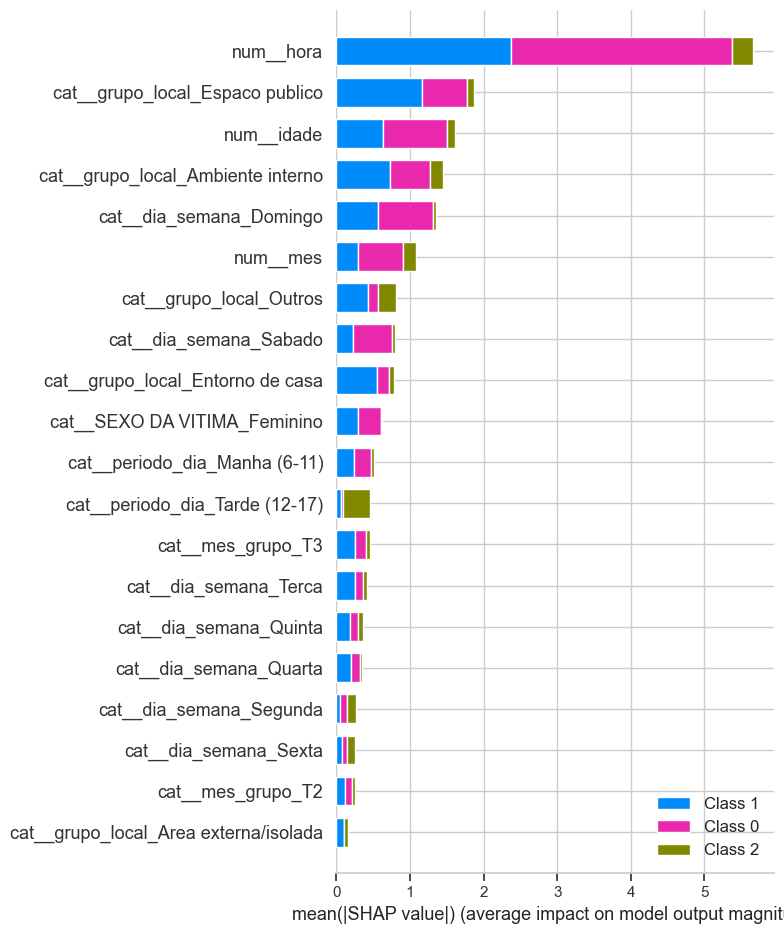

SHAP plots salvos.


In [12]:
# Garantir que pipe_melhor esta fitado com os dados corretos (string labels)
if melhor == 'XGBoost':
    pipe_melhor = resultados['XGBoost']['pipe']
    pipe_melhor.fit(X_train, y_train_enc)
else:
    pipe_melhor = modelos[melhor]
    pipe_melhor.fit(X_train, y_train)

# SHAP so funciona bem com arvores (RandomForest, XGBoost)
if melhor in ['RandomForest', 'XGBoost']:
    preproc = pipe_melhor.named_steps['preprocessor']
    clf_inner = pipe_melhor.named_steps['clf']
    
    X_train_trans = preproc.transform(X_train)
    X_test_trans = preproc.transform(X_test)
    feature_names = preproc.get_feature_names_out()
    X_train_df = pd.DataFrame(X_train_trans, columns=feature_names)
    X_test_df = pd.DataFrame(X_test_trans, columns=feature_names)
    
    explainer = shap.TreeExplainer(clf_inner)
    shap_values = explainer.shap_values(X_test_df[:200])
    
    plt.figure(figsize=(10, 6))
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[2], X_test_df[:200], show=False, plot_type='bar')
    else:
        shap.summary_plot(shap_values, X_test_df[:200], show=False, plot_type='bar')
    plt.tight_layout()
    plt.savefig(MODELS_DIR.parent / 'data' / 'processed' / 'shap_summary.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    y_pred_test = pipe_melhor.predict(X_test)
    idx_alta = np.where(y_pred_test == 'alta')[0]
    if len(idx_alta) > 0:
        idx = idx_alta[0]
        if isinstance(shap_values, list):
            sv_class = shap_values[0][idx]
            bv = explainer.expected_value[0]
        else:
            sv_class = shap_values[idx, :, 0]
            bv = explainer.expected_value[0]
        
        plt.figure(figsize=(10, 5))
        shap.plots.waterfall(
            shap.Explanation(
                values=sv_class,
                base_values=bv,
                data=X_test_df.iloc[idx].values,
                feature_names=feature_names
            ),
            show=False
        )
        plt.tight_layout()
        plt.savefig(MODELS_DIR.parent / 'data' / 'processed' / 'shap_waterfall_exemplo.png', dpi=100, bbox_inches='tight')
        plt.show()
    print('SHAP plots salvos.')
else:
    print(f'SHAP nao aplicado (modelo {melhor} nao baseado em arvores).')

## 8. Serializacao do modelo + encoder

In [13]:
# Salvar pipeline completo (preprocessor + clf)
model_path = MODELS_DIR / "preditor_maceio.joblib"
joblib.dump(pipe_melhor, model_path)
print(f"Modelo salvo: {model_path}")
print(f"Tamanho: {model_path.stat().st_size / 1024:.1f} KB")

# Salvar LabelEncoder junto (CRITICO: ordem canonica!)
le_path = MODELS_DIR / "label_encoder.joblib"
joblib.dump(le, le_path)
print(f"LabelEncoder salvo: {le_path}")
print(f"Mapping real: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Salvar metadados
meta = {
    "modelo": melhor,
    "features_num": features_num,
    "features_cat": features_cat,
    "segment_cols": ["SEXO DA VITIMA", "faixa_etaria"],  # grupo demografico
    "target_design": "rank_no_grupo_percentile_within_demo_group",
    "classes_canonicas": ["baixa", "media", "alta"],
    "label_encoder_classes": list(le.classes_),
    "label_encoder_mapping": {str(c): int(i) for c, i in zip(le.classes_, le.transform(le.classes_))},
    "f1_macro_cv": float(np.mean(cv_resultados[melhor]["f1"])),
    "n_amostras_treino": int(len(X_train)),
    "n_amostras_teste": int(len(X_test)),
}
meta_path = MODELS_DIR / "preditor_meta.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print(f"Metadados salvos: {meta_path}")

Modelo salvo: ../models/preditor_maceio.joblib
Tamanho: 2164.3 KB
LabelEncoder salvo: ../models/label_encoder.joblib
Mapping real: {np.str_('alta'): np.int64(0), np.str_('baixa'): np.int64(1), np.str_('media'): np.int64(2)}
Metadados salvos: ../models/preditor_meta.json


In [14]:
# Teste de carga
loaded = joblib.load(model_path)
sample = X_test.head(3)
print('Teste de carga:')
print(loaded.predict(sample))

Teste de carga:
[1 0 2]


## 9. Resumo final

| Item | Valor |
|---|---|
| Registros Maceio | ~6.8k |
| Segmentos unicos | variavel |
| Cortes (tercis) | q33=?, q66=? |
| Distribuicao classes | ~33% cada |
| Melhor modelo | ? |
| F1 macro (5-fold CV) | ? |
| Artefatos | `models/preditor_maceio.joblib`, `models/preditor_meta.json` |

Proxima etapa: Streamlit dashboard (T021-T022).